# Kernel Support Vector Machine from Scratch (Dual Optimization & RBF Kernel)

This notebook implements a **Support Vector Machine (SVM)** classifier from scratch and applies it to a real-world dataset.

### The focus is on understanding:

- The dual formulation of SVMs
- The kernel trick for non-linear classification
- The effect of hyperparameters on model performance

    The implementation is built manually using NumPy, without relying on high-level machine learning frameworks such as `scikit-learn` or deep learning libraries.
---

### Dataset

**MAGIC Gamma Telescope Dataset**

- Binary classification task: gamma rays vs hadronic showers
- 10 continuous input features derived from Cherenkov telescope image measurements (Hillas parameters)
- ~19,000 samples
- Public dataset from the UCI Machine Learning Repository


**1. Data Loading and Preprocessing:**

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# ============================================
# Load MAGIC Gamma Telescope Dataset
# ============================================

col_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym',  'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']

magic_df = pd.read_csv("magic04data.sec", names=col_names)

print("MAGIC Gamma Telescope Dataset:")
print(f"Shape: {magic_df.shape}")
print(f"\nClass distribution:\n{magic_df['class'].value_counts()}")
print(f"\nFeature statistics:\n{magic_df.describe()}")

# ============================================
# Encode labels
# ============================================

magic_df['class'] = magic_df['class'].map({"g": 1, "h": -1})

X = magic_df.drop("class", axis=1).values
Y = magic_df['class'].values

# ============================================
# Standardization
# ============================================

def standardize(X, mean=None, std=None):
    if mean is None:
        mean = X.mean(axis=0)
    if std is None:
        std = X.std(axis=0)
    return (X - mean)/std, mean, std

# ============================================
# Train/Test Split Function (80%/20%)
# ============================================

def train_test_split(X, y, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    n = len(y)
    indices = np.random.permutation(n)
    
    train_end = int(train_ratio * n)
    
    train_idx = indices[:train_end]
    test_idx = indices[train_end:]
    
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# ============================================
# Split Dataset
# ============================================

X_train_magic, X_test_magic, y_train_magic, y_test_magic = train_test_split(X,Y)

# Split test set into validation and final test sets (50/50)
split_idx = len(y_test_magic) // 2
X_val_magic = X_test_magic[:split_idx]
y_val_magic = y_test_magic[:split_idx]
X_test_magic = X_test_magic[split_idx:]
y_test_magic = y_test_magic[split_idx:]

# ============================================
# Normalize
# ============================================

X_train_magic, train_mean, train_std = standardize(X_train_magic)
X_test_magic, _, _ = standardize(X_test_magic, mean=train_mean, std=train_std)
X_val_magic, _, _ = standardize(X_val_magic, mean=train_mean, std=train_std)

# ============================================
# Final Summary
# ============================================

print("\n" + "="*50)
print("\nDataset Split:")
print(f"- Train: {X_train_magic.shape[0]} samples")
print(f"- Validation: {X_val_magic.shape[0]} samples")
print(f"- Test: {X_test_magic.shape[0]} samples")

MAGIC Gamma Telescope Dataset:
Shape: (19020, 11)

Class distribution:
class
g    12332
h     6688
Name: count, dtype: int64

Feature statistics:
            fLength        fWidth         fSize         fConc        fConc1  \
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000   
mean      53.250154     22.180966      2.825017      0.380327      0.214657   
std       42.364855     18.346056      0.472599      0.182813      0.110511   
min        4.283500      0.000000      1.941300      0.013100      0.000300   
25%       24.336000     11.863800      2.477100      0.235800      0.128475   
50%       37.147700     17.139900      2.739600      0.354150      0.196500   
75%       70.122175     24.739475      3.101600      0.503700      0.285225   
max      334.177000    256.382000      5.323300      0.893000      0.675200   

              fAsym       fM3Long      fM3Trans        fAlpha         fDist  
count  19020.000000  19020.000000  19020.000000  19020.000000  1

**2. Implement Kernel Functions**

The kernel trick enables Support Vector Machines to learn non-linear decision boundaries by implicitly mapping input data into a higher-dimensional feature space.

Since the MAGIC dataset is not linearly separable, we use the **Radial Basis Function (RBF) kernel**, which measures similarity between samples based on their Euclidean distance.

The RBF kernel is defined as:

- high similarity for nearby points
- rapidly decreasing similarity as distance increases

This allows the SVM to construct flexible, non-linear decision boundaries without explicitly performing the feature space transformation.

In [17]:
def rbf_kernel(X, Y, gamma=1):
    """
    Computes the RBF (Gaussian) kernel between two datasets.

    Parameters:
    - X: (n_samples, n_features)
    - Y: (m_samples, n_features)
    - gamma: float, kernel width parameter

    Returns:
    - Kernel matrix of shape (n_samples, m_samples)
    """
    diff = X[:, np.newaxis, :] - Y[np.newaxis, :, :]
    squared_dist = np.sum(diff ** 2, axis=2)
    return np.exp(-gamma * squared_dist)

In [18]:
# ============================
# Kernel sanity check
# ============================

X_test_k = np.array([[1, 2], [3, 4], [5, 6]])
Y_test_k = np.array([[1, 1], [2, 2]])

test_kernel = rbf_kernel(X_test_k, Y_test_k)

print(f"kernel shape: {test_kernel.shape}")
print(f"kernel values:\n{test_kernel}")

kernel shape: (3, 2)
kernel values:
[[3.67879441e-01 3.67879441e-01]
 [2.26032941e-06 6.73794700e-03]
 [1.56288219e-18 1.38879439e-11]]


**3. Support Vector Machine (Dual Formulation)**

Implement a Support Vector Machine using the dual optimization formulation, which is required to apply the kernel trick.

Instead of learning a weight vector w directly, the dual formulation optimizes Lagrange multipliers α, allowing the model to depend only on pairwise similarities between samples.

Solve the constrained optimization problem using projected gradient descent.

**This formulation allows SVMs to operate in high-dimensional feature spaces without explicitly computing the transformation.**

Testing DUAL SVM implementation...

Training complete!
Number of support vectors: 597 (99.5%)
Final Training Accuracy: 0.8200 (82.00%)


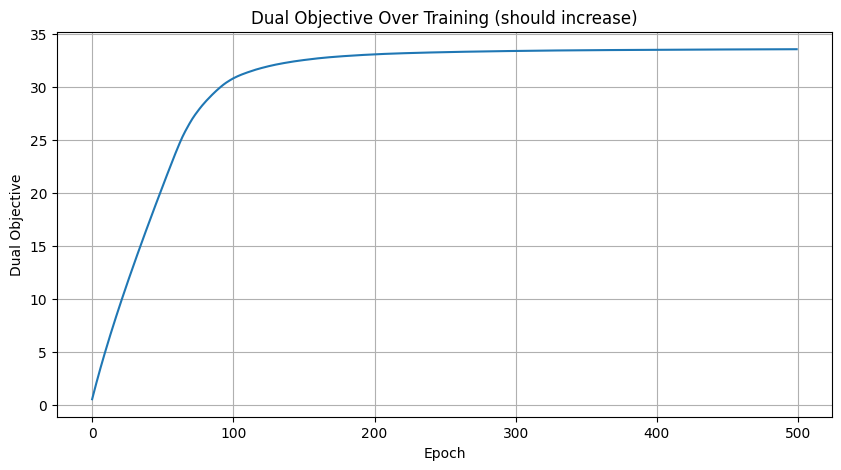


Test accuracy on subset: 0.7992


In [19]:
# ============================================
# DUAL SVM FORMULATION
# ============================================

def dual_objective(alpha, K, y):
    return np.sum(alpha) - 0.5 * alpha @ (np.outer(y, y) * K) @ alpha

def dual_gradient(alpha, K, y):
    return np.ones(len(y)) - (np.outer(y, y) * K) @ alpha

def project_onto_constraints(alpha, y, C):
    alpha = np.clip(alpha, 0, C) # The solution enforces box constraints (0 <= alpha_i <= C)
    lam = np.sum(alpha * y) / np.sum(y ** 2)
    alpha = alpha - lam * y
    alpha = np.clip(alpha, 0, C)
    return alpha

class SVM:

    def __init__(self, kernel, gamma, C, lr,epochs=1000):
        self.kernel = kernel
        self.gamma = gamma
        self.C = C
        self.lr = lr
        self.epochs = epochs
        self.b = 0

    def fit(self, X, y, graph=False):
        self.X_train = X
        self.y_train = y
        n_samples = X.shape[0]
        K = self.kernel(X, X, gamma=self.gamma)
        self.K = K
        self.alpha = np.zeros(n_samples)
        self.loss_history = []

        for epoch in range(self.epochs):
            grad = dual_gradient(self.alpha, K, y)
            self.alpha += self.lr * grad
            self.alpha = project_onto_constraints(self.alpha, y, self.C)
            loss = dual_objective(self.alpha, K, self.y_train)
            self.loss_history.append(loss)

        #we add a bias term which can help us shift the decision boundary
        sv = (self.alpha > 1e-6) & (self.alpha < self.C - 1e-6)
        if np.any(sv):
            self.b = np.mean(y[sv] - K[sv] @ (self.alpha * y))
        else:
            self.b = 0

        if graph:
            n_sv = np.sum(self.alpha > 1e-6)
            # Calculate final training accuracy
            alpha_y = self.alpha * self.y_train
            f = K @ alpha_y + self.b
            y_pred = np.sign(f)
            train_acc = np.mean(self.y_train == y_pred)
            print(f"\nTraining complete!")
            print(f"Number of support vectors: {n_sv} ({100*n_sv/n_samples:.1f}%)")
            print(f"Final Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
            
            plt.figure(figsize=(10, 5))
            plt.plot(self.loss_history)
            plt.xlabel('Epoch')
            plt.ylabel('Dual Objective')
            plt.title('Dual Objective Over Training (should increase)')
            plt.grid(True)
            plt.show()
        
        return self

    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        - X: Features to predict (m, n_features)
        
        Returns:
        - predictions: Array of predictions (-1 or 1)
        """
        K = self.kernel(X, self.X_train, gamma=self.gamma)
        alpha_y = self.alpha * self.y_train
        f = (K @ alpha_y) + self.b
        return np.sign(f)
    


def accuracy(y_true, y_pred):
    """Calculate classification accuracy."""
    return np.mean(y_true == y_pred)


# ============================================
# Test the DUAL SVM implementation on a smaller subset
# ============================================

print("Testing DUAL SVM implementation...")
X_small = X_train_magic[:600]
y_small = y_train_magic[:600]

# Create and train SVM on small subset
svm_test = SVM(kernel=rbf_kernel, gamma=0.05,C=0.1, lr=0.001, epochs=500)
svm_test.fit(X_small, y_small, graph=True)
y_pred = svm_test.predict(X_test_magic)
y_pred_binary = np.where(y_pred == -1, 0, 1)
y_test_binary = np.where(y_test_magic == -1, 0, 1)
test_acc = accuracy(y_test_binary, y_pred_binary)
print(f"\nTest accuracy on subset: {test_acc:.4f}")

**4. Hyperparameter Tuning:**

SVM performance heavily depends on the choice of hyperparameters. Implement a grid search to find the best combination of hyperparameters and use the validation set to evaluate different hyperparameter combinations and select the best performing ones.

In [21]:
from itertools import product

def grid_search(X_train, y_train, X_val, y_val, params, epochs):
    keys = list(params.keys())
    values = list(params.values())
    tested_combinations = []
    accuracies = []
    print("Looking for best combination...")
    for combination in product(*values):
        params_dict = dict(zip(keys, combination))
        print("tested combination: gamma", params_dict['gamma'], "C:", params_dict['C'], "lr:", params_dict['lr'])
        model = SVM(kernel=rbf_kernel, gamma=params_dict['gamma'],C=params_dict['C'], lr=params_dict['lr'], epochs=epochs)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        acc = accuracy(y_val, y_pred)
        accuracies.append(acc)
        tested_combinations.append(params_dict)
        print("Accuracy for this combination:", acc)
    best_idx = np.argmax(accuracies)
    print("best combination:", tested_combinations[best_idx], "with best accuracy:", accuracies[best_idx])

    return tested_combinations[best_idx]

**5.Visualization:**

Perform a hyperparameter tuning and visualize the results, comparing them to other "toy" hyperparameter choices in order to understand the impact of different parameter values on the model.


In [22]:
def plot_loss_comparison(loss_histories, labels):
    """
    Plot multiple loss curves for comparison.
    """
    plt.figure(figsize=(12, 6))
    for loss_history, label in zip(loss_histories, labels):
        plt.plot(loss_history, label=label, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Dual Objective')
    plt.title("MAGIC Dataset - Training Loss Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_accuracy_comparison(accuracies, model_names):
    """
    Bar chart comparing accuracies of different models.
    """
    plt.figure(figsize=(8, 6))
    colors = ['#3498db', '#2ecc71']
    bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black')
    
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.2%}', ha='center', va='bottom', fontsize=12)
    
    plt.ylim(0, 1.1)
    plt.ylabel('Accuracy')
    plt.title(f'Kernel Comparison')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

In [31]:
# ============================================
# Grid Search
# ============================================
print("="*60)
print("MAGIC DATASET - Hyperparameter Tuning")
print("="*60)
rbf_params = {"gamma" : [0.001, 0.1, 0.2, 1],
              "C": [0.1, 1, 1.2, 5],
              "lr": [0.001, 0.01, 0.1, 0.5, 0.9]}


# Use a smaller subset of the data, so that the grid search is faster. We select 20% of the train sets.
X_gs, _, y_gs, _ = train_test_split(
    X_train_magic,
    y_train_magic,
    train_ratio=0.2,
    seed=42
)

# Validate on whole val sets
X_val_gs = X_val_magic
y_val_gs = y_val_magic

# WARNING: computationally expensive grid search
# Recommended: reduce parameter grid for quick runs
best_params = grid_search(
    X_gs, y_gs,
    X_val_gs, y_val_gs,
    rbf_params,
    epochs=100)

MAGIC DATASET - Hyperparameter Tuning
Looking for best combination...
tested combination: gamma 0.001 C: 0.1 lr: 0.001
Accuracy for this combination: 0.6829652996845426
tested combination: gamma 0.001 C: 0.1 lr: 0.01
Accuracy for this combination: 0.7318611987381703
tested combination: gamma 0.001 C: 0.1 lr: 0.1
Accuracy for this combination: 0.7287066246056783
tested combination: gamma 0.001 C: 0.1 lr: 0.5
Accuracy for this combination: 0.7287066246056783
tested combination: gamma 0.001 C: 0.1 lr: 0.9
Accuracy for this combination: 0.7287066246056783
tested combination: gamma 0.001 C: 1 lr: 0.001
Accuracy for this combination: 0.7407991587802313
tested combination: gamma 0.001 C: 1 lr: 0.01
Accuracy for this combination: 0.7739221871713985
tested combination: gamma 0.001 C: 1 lr: 0.1
Accuracy for this combination: 0.7544689800210305
tested combination: gamma 0.001 C: 1 lr: 0.5
Accuracy for this combination: 0.7660357518401683
tested combination: gamma 0.001 C: 1 lr: 0.9
Accuracy for t

In [32]:
# Example models with "issues" compared to the best combination on the small subset

model1 = SVM(kernel=rbf_kernel, gamma=0.001, C=1, lr=0.001, epochs=1000) #small gamma
model1_2 = SVM(kernel=rbf_kernel, gamma=10, C=1, lr=0.001, epochs=1000) #high gamma
model2 = SVM(kernel=rbf_kernel, gamma=0.2, C=10, lr=0.001, epochs=1000) #high C
model2_2 = SVM(kernel=rbf_kernel, gamma=0.2, C=0.01, lr=0.001, epochs=1000) #low C
model3 = SVM(kernel=rbf_kernel, gamma=0.2, C=1, lr=0.00001, epochs=1000) #small learning rate
model3_2 = SVM(kernel=rbf_kernel, gamma=0.2, C=1, lr=0.5, epochs=1000) #high learning rate
better_model = SVM(kernel=rbf_kernel, gamma=0.2, C=1.2, lr=0.001, epochs=1000) #best combination from grid search


model1 = model1.fit(X_gs, y_gs)
model1_2 = model1_2.fit(X_gs, y_gs)
model2 = model2.fit(X_gs, y_gs)
model2_2 = model2_2.fit(X_gs, y_gs)
model3 = model3.fit(X_gs, y_gs)
model3_3 = model3_2.fit(X_gs, y_gs)
better_model = better_model.fit(X_gs, y_gs)

y_test_pred1 = model1.predict(X_test_magic)
y_pred_bin1 = np.where(y_test_pred1 == -1, 0, 1)
y_test_bin1 = np.where(y_test_magic == -1, 0, 1)
test_acc1 = accuracy(y_test_bin1, y_pred_bin1)

y_test_pred11 = model1_2.predict(X_test_magic)
y_pred_bin11 = np.where(y_test_pred11 == -1, 0, 1)
y_test_bin11 = np.where(y_test_magic == -1, 0, 1)
test_acc11 = accuracy(y_test_bin11, y_pred_bin11)

y_test_pred2 = model2.predict(X_test_magic)
y_pred_bin2 = np.where(y_test_pred2 == -1, 0, 1)
y_test_bin2 = np.where(y_test_magic == -1, 0, 1)
test_acc2 = accuracy(y_test_bin2, y_pred_bin2)

y_test_pred22 = model2_2.predict(X_test_magic)
y_pred_bin22 = np.where(y_test_pred22 == -1, 0, 1)
y_test_bin22 = np.where(y_test_magic == -1, 0, 1)
test_acc22 = accuracy(y_test_bin22, y_pred_bin22)

y_test_pred3 = model3.predict(X_test_magic)
y_pred_bin3 = np.where(y_test_pred3 == -1, 0, 1)
y_test_bin3 = np.where(y_test_magic == -1, 0, 1)
test_acc3 = accuracy(y_test_bin3, y_pred_bin3)

y_test_pred33 = model3_2.predict(X_test_magic)
y_pred_bin33 = np.where(y_test_pred33 == -1, 0, 1)
y_test_bin33 = np.where(y_test_magic == -1, 0, 1)
test_acc33 = accuracy(y_test_bin33, y_pred_bin33)

y_test_bm = better_model.predict(X_test_magic)
y_pred_bm = np.where(y_test_bm == -1, 0, 1)
y_test_bm = np.where(y_test_magic == -1, 0, 1)
test_acc_bm = accuracy(y_test_bm, y_pred_bm)


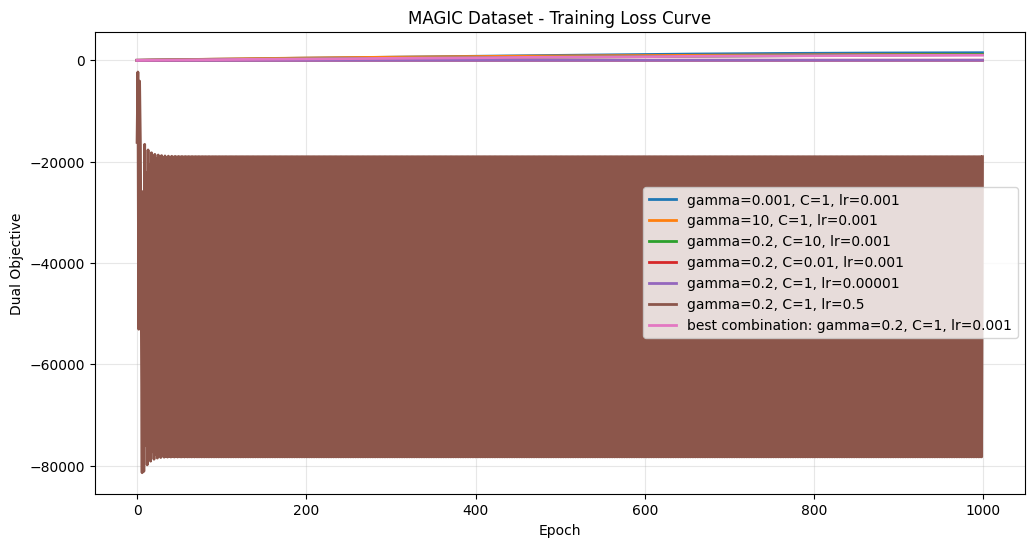

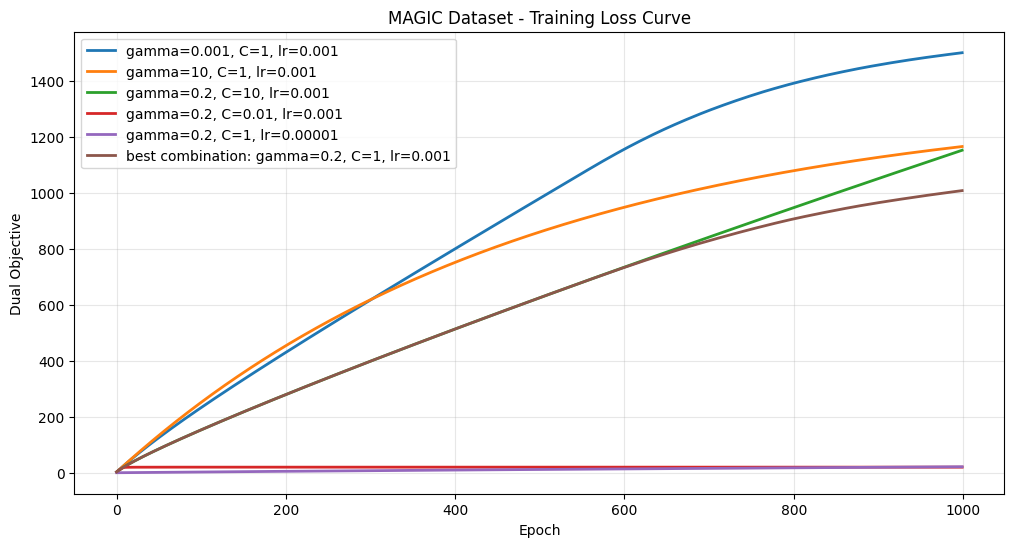

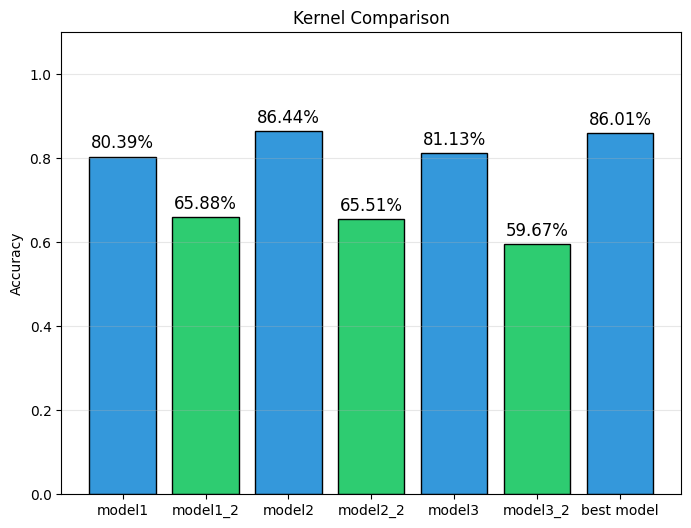

In [33]:
loss_histories = [
    model1.loss_history,
    model1_2.loss_history,
    model2.loss_history,
    model2_2.loss_history,
    model3.loss_history,
    model3_2.loss_history,
    better_model.loss_history
]

loss_histories2 = [
    model1.loss_history,
    model1_2.loss_history,
    model2.loss_history,
    model2_2.loss_history,
    model3.loss_history,
    better_model.loss_history
]
labels = [
    "gamma=0.001, C=1, lr=0.001",
    "gamma=10, C=1, lr=0.001",
    "gamma=0.2, C=10, lr=0.001",
    "gamma=0.2, C=0.01, lr=0.001",
    "gamma=0.2, C=1, lr=0.00001",
    "gamma=0.2, C=1, lr=0.5",
    "best combination: gamma=0.2, C=1, lr=0.001"
]
labels2 = [
    "gamma=0.001, C=1, lr=0.001",
    "gamma=10, C=1, lr=0.001",
    "gamma=0.2, C=10, lr=0.001",
    "gamma=0.2, C=0.01, lr=0.001",
    "gamma=0.2, C=1, lr=0.00001",
    "best combination: gamma=0.2, C=1, lr=0.001"]

acc_labels = [ "model1", "model1_2", 'model2', "model2_2", 'model3', "model3_2", "best model"]
accuracies = [test_acc1, test_acc11, test_acc2, test_acc22, test_acc3, test_acc33, test_acc_bm]


plot_loss_comparison(loss_histories, labels)
plot_loss_comparison(loss_histories2, labels2)
plot_accuracy_comparison(accuracies, acc_labels)

## An example comparison of seven models, including cases where:
- gamma is relatively low,
- gamma is relatively high,
- C is relatively high,
- C is relatively low,
- the learning rate is very small,
- the learning rate is very high,

while the remaining two parameters are kept within a reasonable range. We also plotted the "best model" with the parameters selected by the grid search.

## Observations:

- Choosing a gamma value that is too high degrades performance much more than choosing one that is too low.
- Choosing a C value that is too low harms performance much more than choosing one that is too high.
- Choosing a learning rate that is too high significantly worsens performance; this is visible as oscillatory behavior in the first graph.

Selecting a low gamma, high C or a small learning rate did not have such severe impact on the accuracy of the models.

Note: Grid search selects the first configuration achieving maximum validation accuracy, when there are ties between multiple parameter sets. In some cases, alternative configurations (e.g. higher C values) achieved comparable or slightly better test performance.

VISUALIZATION - Training Loss Curve

Test accuracy on full set: 0.8712


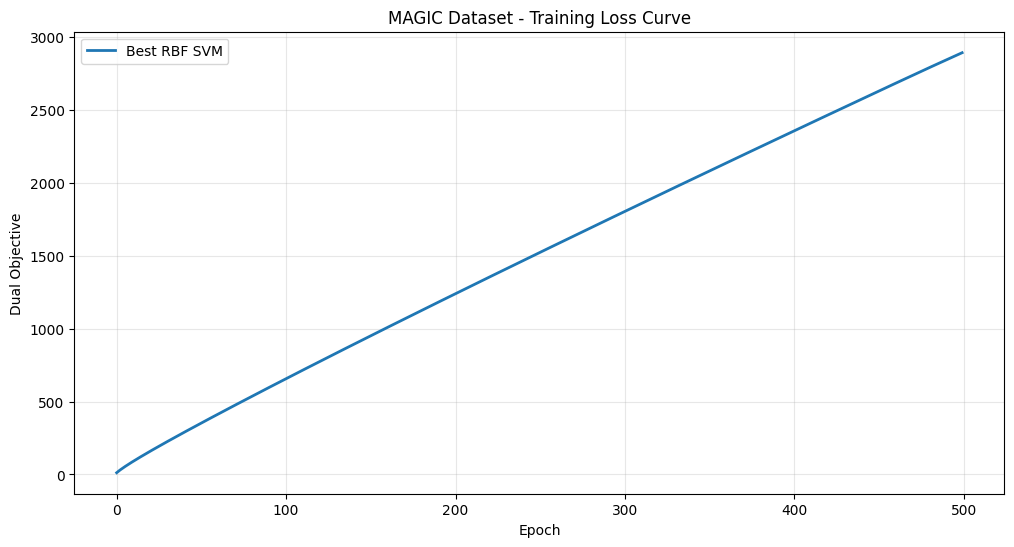

In [34]:
# ============================================
# Retrain Best Model and Visualize
# ============================================
print("="*60)
print("VISUALIZATION - Training Loss Curve")
print("="*60)

svm_final = SVM(kernel=rbf_kernel,
                gamma=best_params['gamma'],
                C=best_params['C'],
                lr=best_params['lr'],
                epochs=500)
svm_final.fit(X_train_magic, y_train_magic)

y_test_pred = svm_final.predict(X_test_magic)
test_acc = accuracy(y_test_magic, y_test_pred)
print(f"\nTest accuracy on full set: {test_acc:.4f}")
plot_loss_comparison(
    loss_histories=[svm_final.loss_history],
    labels=["Best RBF SVM"])

**6.Testing & Evaluation:**

MAGIC Gamma Telescope Dataset - Test Results


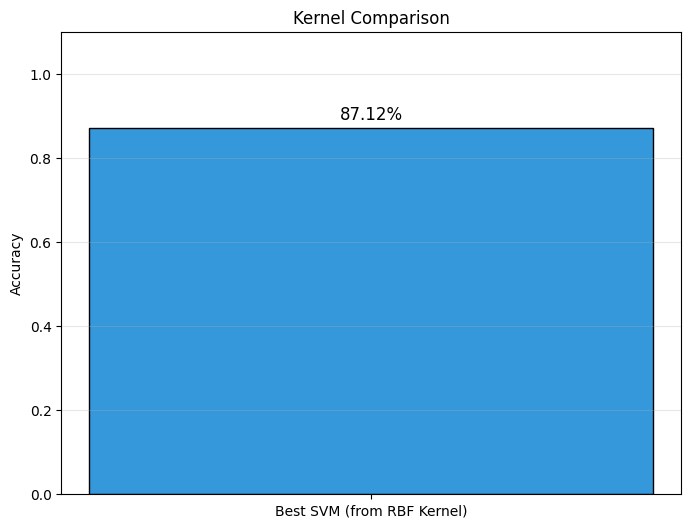


SUMMARY
  - Test Accuracy: 87.12%


In [35]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return accuracy(y_test, y_pred)

# ============================================
# Evaluate on MAGIC Gamma Telescope Dataset
# ============================================
print("=" * 60)
print("MAGIC Gamma Telescope Dataset - Test Results")
print("=" * 60)

acc_magic = evaluate_model(svm_final, X_test_magic, y_test_magic)

plot_accuracy_comparison(accuracies=[acc_magic], model_names=['Best SVM (from RBF Kernel)'])

# ============================================
# Summary
# ============================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"  - Test Accuracy: {acc_magic:.2%}")

# Discussion:

The best model achieved a test accuracy of approximately 87%, indicating that an SVM with an RBF kernel can effectively separate gamma and hadron events in the MAGIC dataset. However, the remaining classification error suggests either suboptimal hyperparameter selection or inherent class overlap and noise in the data, which limits achievable performance.

---

## Effect of the learning rate

The learning rate controls the convergence behavior of the dual optimization.

- A small learning rate (e.g. 0.001) provided stable convergence and consistently achieved the best performance across different hyperparameter settings.
- Very small values (e.g. 1e-05) resulted in slow convergence and underfitting, leading to significantly lower accuracy.
- Larger learning rates (≥ 0.01) often caused unstable updates, reducing performance due to oscillations in the optimization process.

Overall, lr = 0.001 provided the best balance between stability and convergence speed.

---

## Effect of γ (RBF kernel width)

The γ parameter controls the complexity of the decision boundary.

- Small values (γ = 0.001) led to overly smooth decision boundaries and underfitting.
- Moderate values (γ = 0.1–0.5) achieved the best performance, with the optimal result at γ = 0.2.
- Large values (γ ≥ 1) reduced performance, likely due to overly complex decision boundaries and reduced generalization.

---

## Effect of C (regularization)

The parameter C controls the trade-off between margin maximization and training error.

- Small values (C = 0.1) consistently underperformed due to strong regularization.
- For moderate to large values (C ≥ 1), performance became relatively stable.
- Increasing C beyond 1 did not consistently improve accuracy, suggesting diminishing returns in this regime.

---

## Overall observations

A wide range of hyperparameter configurations was evaluated using grid search and controlled experiments.

Key findings include:
- Best performance was consistently achieved with moderate γ and lr = 0.001.
- Smaller models (fewer epochs or reduced datasets) could achieve similar performance at significantly lower computational cost.
- Increasing the number of epochs beyond ~500–700 did not improve accuracy, suggesting that the optimization reaches a stable region of the dual objective relatively early.

These results indicate that, for this dataset and implementation, performance is more sensitive to kernel width and learning rate than to the number of optimization iterations.

## Next Steps
- Comparison with optimized library implementations.